In [1]:
# 1.1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Optional: make plots prettier
sns.set(style="whitegrid")

import pandas as pd
df = pd.read_csv("AmesHousing.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [2]:
# -------------------------------
# Step 2: Check missing values
# -------------------------------
nan_count = df.isnull().sum()
nan_percent = df.isnull().mean() * 100

print("\n=== Missing Values Count ===")
print(nan_count[nan_count > 0])

print("\n=== Missing Values Percentage ===")
print(nan_percent[nan_percent > 0])


=== Missing Values Count ===
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

=== Missing Values Percentage ===
Lot Frontage      16.723549
Alley             93.242321
Mas Vnr Type      60.580205
Mas Vnr Area       0.784983
Bsmt Qual          2.730375
Bsmt Cond          2.730375
Bsmt Exposure      2.832765
BsmtFin Type 1     2.730375
BsmtFin SF 1       0.034130
BsmtFin Type 2     2.764505
BsmtFin SF 2       0.

In [5]:
# -------------------------------
# Step 3: Imputation (Numerical)
# -------------------------------
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns:", numeric_cols)

# Save a copy without imputation for comparison
df_original = df.copy()

# Mean imputation
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())



Numeric columns: ['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold', 'SalePrice']


In [7]:
example_cols = numeric_cols[:5]  # take first 5 numeric features

stats_before = df[example_cols].agg(['min','max','mean','std'])
stats_after  = df_scaled[example_cols].agg(['min','max','mean','std'])

print("\n=== Stats before scaling (sample) ===")
print(stats_before.round(3))
print("\n=== Stats after scaling (sample) ===")
print(stats_after.round(3))



=== Stats before scaling (sample) ===
         Order           PID  MS SubClass  Lot Frontage    Lot Area
min      1.000  5.263011e+08       20.000        21.000    1300.000
max   2930.000  1.007100e+09      190.000       313.000  215245.000
mean  1465.500  7.144645e+08       57.387        69.225   10147.922
std    845.962  1.887308e+08       42.638        21.322    7880.018

=== Stats after scaling (sample) ===
      Order    PID  MS SubClass  Lot Frontage  Lot Area
min  -1.731 -0.997       -0.877        -2.262    -1.123
max   1.731  1.551        3.111        11.435    26.032
mean  0.000 -0.000       -0.000         0.000     0.000
std   1.000  1.000        1.000         1.000     1.000


In [8]:
example_cols = numeric_cols[:5]

print("\nMean after scaling:")
print(df_scaled[example_cols].mean().round(3))

print("\nStd after scaling:")
print(df_scaled[example_cols].std().round(3))



Mean after scaling:
Order           0.0
PID            -0.0
MS SubClass    -0.0
Lot Frontage    0.0
Lot Area        0.0
dtype: float64

Std after scaling:
Order           1.0
PID             1.0
MS SubClass     1.0
Lot Frontage    1.0
Lot Area        1.0
dtype: float64


In [9]:
col = numeric_cols[0]

print(f"\nFeature: {col}")
print("Before:", df[col].describe()[['min','mean','std','max']])
print("After :", df_scaled[col].describe()[['min','mean','std','max']])



Feature: Order
Before: min        1.00000
mean    1465.50000
std      845.96247
max     2930.00000
Name: Order, dtype: float64
After : min    -1.731460
mean    0.000000
std     1.000171
max     1.731460
Name: Order, dtype: float64


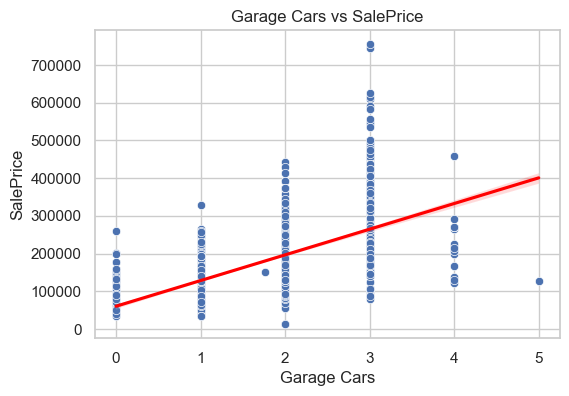

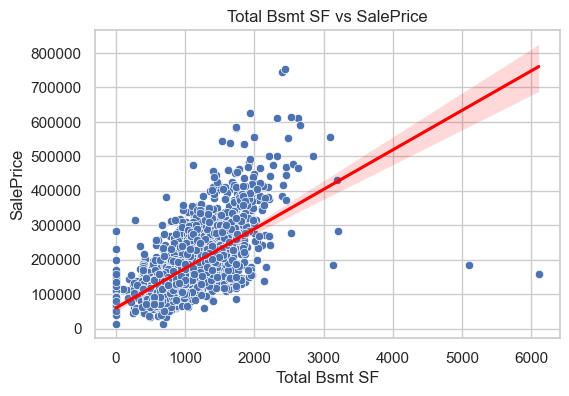

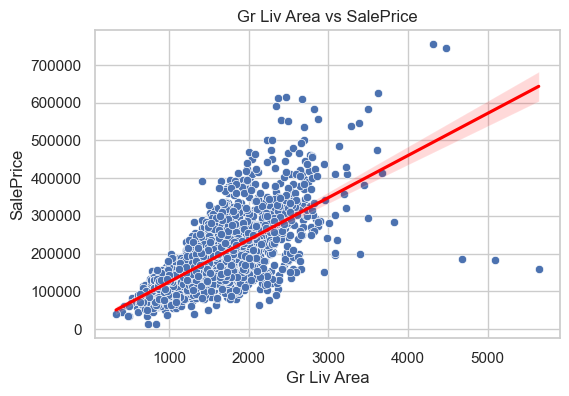

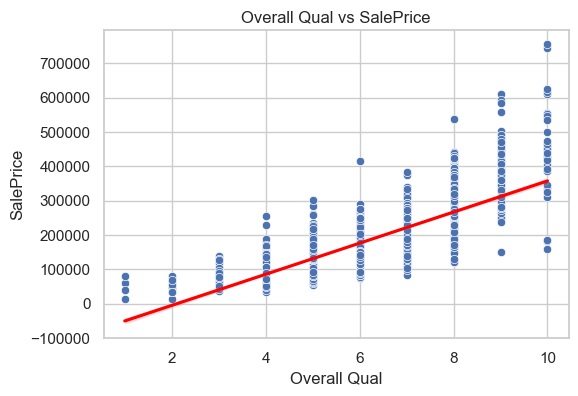

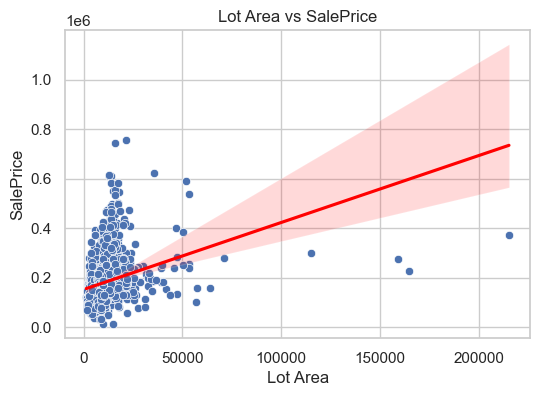

In [10]:
# -------------------------------
# Step 5: Scatter plots against SalePrice
# -------------------------------

features_to_plot = ['Garage Cars', 'Total Bsmt SF', 'Gr Liv Area', 'Overall Qual', 'Lot Area']

for feat in features_to_plot:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=feat, y='SalePrice')
    
    # Add simple linear regression line (OLS)
    sns.regplot(data=df, x=feat, y='SalePrice', scatter=False, color='red')
    
    plt.title(f'{feat} vs SalePrice')
    plt.show()


In [12]:
# -------------------------------
# Step 6: Detect outliers (using z-score)
# -------------------------------
from scipy.stats import zscore

# 1. Compute z-scores
z_scores = df[numeric_cols].apply(zscore)

print("\nZ-score stats (mean/std, should be ~0/1):")
print(z_scores.agg(['mean','std']).round(3).iloc[:, :5])  # only first 5 features

# 2. Boolean mask of outliers
outliers = (np.abs(z_scores) > 3)

# 3. Count outliers per feature
outliers_per_feature = outliers.sum().sort_values(ascending=False)

print("\nOutliers per feature (top 5):")
print(outliers_per_feature.head())

# 4. Rows that have at least one outlier feature
outlier_indices = np.where(outliers.any(axis=1))[0]

print(f"\nTotal rows with at least one outlier: {len(outlier_indices)}")
print(f"First 10 outlier row indices: {outlier_indices[:10]}")

# 5. Show concrete examples (first 3 outlier rows)
print("\nExample outlier rows (values):")
display(df.loc[outlier_indices[:3], numeric_cols[:5]])

print("\nCorresponding z-scores:")
display(z_scores.loc[outlier_indices[:3], numeric_cols[:5]].round(2))



Z-score stats (mean/std, should be ~0/1):
      Order  PID  MS SubClass  Lot Frontage  Lot Area
mean    0.0 -0.0         -0.0           0.0       0.0
std     1.0  1.0          1.0           1.0       1.0

Outliers per feature (top 5):
Bsmt Half Bath    175
Kitchen AbvGr     134
Screen Porch      107
BsmtFin SF 2       92
Enclosed Porch     88
dtype: int64

Total rows with at least one outlier: 878
First 10 outlier row indices: [ 0  2 11 14 15 16 17 18 44 46]

Example outlier rows (values):


,Order,PID,MS SubClass,Lot Frontage,Lot Area
0,1,526301100,20,141.00000,31770
2,3,526351010,20,81.00000,14267
11,12,527165230,20,69.22459,7980



Corresponding z-scores:


,Order,PID,MS SubClass,Lot Frontage,Lot Area
0,-1.73,-1.00,-0.88,3.37,2.74
2,-1.73,-1.00,-0.88,0.55,0.52
11,-1.72,-0.99,-0.88,0.00,-0.28


In [14]:
# ===============================
# Section 2: SGD Implementation
# ===============================

import numpy as np

class SGDRegressorCustom:
    """
    SGD Regressor with support for OLS, Ridge (L2) and Lasso (L1) using proximal step
    """
    def __init__(self, model_type='plain', lr=0.01, epochs=500, batch_size=16, lmbd=0.1, random_state=42):
        assert model_type in ['plain','ridge','lasso'], "model_type must be 'plain', 'ridge' or 'lasso'"
        self.model_type = model_type
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.lmbd = lmbd
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.train_loss_history = []
        self.val_loss_history = []

    def _compute_loss(self, X, y):
        y_pred = X.dot(self.weights) + self.bias
        mse = np.mean((y - y_pred)**2)
        return mse

    def _proximal_l1(self, w, lr_lmbd):
        # Soft-thresholding operator for Lasso
        return np.sign(w) * np.maximum(np.abs(w) - lr_lmbd, 0.0)

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        np.random.seed(self.random_state)
        n_samples, n_features = X_train.shape
        
        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for epoch in range(1, self.epochs + 1):
            # Shuffle
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_train_shuffled = X_train[indices]
            y_train_shuffled = y_train[indices]

            # Mini-batch loop
            for start in range(0, n_samples, self.batch_size):
                end = start + self.batch_size
                X_batch = X_train_shuffled[start:end]
                y_batch = y_train_shuffled[start:end]

                # Predictions
                y_pred = X_batch.dot(self.weights) + self.bias
                error = y_batch - y_pred

                # Gradient calculation
                grad_w = -2 * X_batch.T.dot(error) / len(X_batch)
                grad_b = -2 * np.mean(error)

                # Regularization
                if self.model_type == 'ridge':
                    grad_w += 2 * self.lmbd * self.weights  # L2 gradient

                # Update weights and bias
                self.weights -= self.lr * grad_w
                self.bias -= self.lr * grad_b

                # Lasso proximal step
                if self.model_type == 'lasso':
                    self.weights = self._proximal_l1(self.weights, self.lr * self.lmbd)

            # Compute epoch loss
            train_loss = self._compute_loss(X_train, y_train)
            self.train_loss_history.append(train_loss)
            
            if X_val is not None and y_val is not None:
                val_loss = self._compute_loss(X_val, y_val)
                self.val_loss_history.append(val_loss)
            
            # Optional: print progress
            if epoch % 50 == 0 or epoch == 1:
                print(f"Epoch {epoch}/{self.epochs} - Train Loss: {train_loss:.4f}" + \
                      (f" - Val Loss: {val_loss:.4f}" if X_val is not None else ""))

    def predict(self, X):
        return X.dot(self.weights) + self.bias


In [ ]:
# ================================
# Step 1: Select Features & Target
# ================================
import numpy as np
from sklearn.model_selection import train_test_split

# Use only numeric columns for simplicity
numeric_cols = df_scaled.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('SalePrice')  # Target variable

X = df_scaled[numeric_cols].values
y = df_scaled['SalePrice'].values

# ================================
# Step 2: Split Data into Train / Val / Test
# ================================
# First, split into train + temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Split temp equally into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# ================================
# Step 3: Train SGD Model
# ================================
model = SGDRegressorCustom(
    model_type='ridge', 
    lr=0.01, 
    epochs=500, 
    batch_size=16, 
    lmbd=0.1
)

model.fit(X_train, y_train, X_val, y_val)

# ================================
# Step 4: Predictions on Test Set
# ================================
y_pred = model.predict(X_test)

# ================================
# Step 5: Plot Train / Validation Loss
# ================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(model.train_loss_history, label='Train Loss')
plt.plot(model.val_loss_history, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Learning Curve')
plt.legend()
plt.show()
